# Hypothesis Testing and t-Tests: From First Principles to Practice

> A self-contained guide for mathematics students

Statistical hypothesis testing is a formal way to ask whether an observed pattern is plausibly explained by random sampling variation. This notebook develops the logic, the mathematics, and the computational workflow—not just a list of rules.

We will use one running question: **a filling machine is calibrated to put 30 mL into each vial. Does a sample provide evidence that its mean fill has changed?**

By the end, you should be able to:

- formulate null and alternative hypotheses;
- explain a p-value correctly;
- derive and calculate a one-sample t-statistic;
- distinguish one-sample, paired, pooled, and Welch t-tests;
- connect two-sided tests to confidence intervals;
- reason about Type I error, Type II error, power, effect size, and multiple testing;
- define time-series stationarity and derive and contrast the ADF and KPSS tests;
- report a result without overstating what the data prove.


In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "font.size": 11})
rng = np.random.default_rng(2026)

print("Ready: NumPy, Polars, Matplotlib, and SciPy imported.")

Ready: NumPy, Polars, Matplotlib, and SciPy imported.


## 1. The statistical problem: population versus sample

A **population parameter** is a fixed but usually unknown number. Here it is the true long-run mean fill, denoted by $\mu$. A **sample statistic**, such as the sample mean $\bar X$, is random because a different sample would contain different vials.

Suppose we observe $X_1,\ldots,X_n$, modeled as independent observations from a population with mean $\mu$ and finite variance $\sigma^2$. Then

$$\mathbb E[\bar X]=\mu, \qquad \operatorname{Var}(\bar X)=\frac{\sigma^2}{n}.$$

The **standard error** of $\bar X$ is therefore $\sigma/\sqrt n$. It measures how much sample means would vary across repeated samples. This is different from the standard deviation $\sigma$, which measures how much individual observations vary.

Because the population standard deviation $\sigma$ is normally unknown, we estimate it with the **sample standard deviation** $S$. Its definition is

$$S^2=\frac{1}{n-1}\sum_{i=1}^n(X_i-\bar X)^2,\qquad S=\sqrt{\frac{1}{n-1}\sum_{i=1}^n(X_i-\bar X)^2}.$$

$S$ measures the spread of the individual sample observations around their sample mean. It has the same units as the observations. The estimated standard error of the sample mean is a different quantity:

$$\widehat{\operatorname{SE}}(\bar X)=\frac{S}{\sqrt n}.$$

### Uppercase $S$ versus lowercase $s$

The distinction is the same as for $X$ and $x$:

- $\sigma$ is the fixed but unknown **population** standard deviation;
- $S$ is the **random sample statistic** before the data are observed—another random sample would generally produce another $S$;
- $s$ is the particular numerical value of $S$ calculated from the observed data.

Many textbooks use $S$ and $s$ somewhat interchangeably. In this notebook, formulas for random variables use uppercase $S$, while calculations from the observed vial data use the Python variable `s`. For that sample, $s=1.2563$ mL and the estimated standard error is $s/\sqrt{12}=0.3627$ mL.

The denominator $n-1$ reflects one lost degree of freedom: after $\bar X$ is fitted, only $n-1$ deviations $X_i-\bar X$ may vary freely because their sum is zero. The next section explains this in detail.


## 1.1 Degrees of freedom: the number of independent directions left

The phrase **degrees of freedom** often sounds more mysterious than the idea itself. Forget statistics for a moment. In mathematics and mechanics, a degree of freedom is an **independent coordinate that may still vary while all constraints are respected**. Statistics uses the same idea.

For a linear problem, the basic rule is

$$\boxed{\text{degrees of freedom}=\text{number of coordinates}-\text{number of independent constraints}.}$$

### The smallest useful example: three deviations

Take three numbers $x_1,x_2,x_3$ and compute their sample mean $\bar x$. Their deviations from that mean are

$$d_1=x_1-\bar x,\qquad d_2=x_2-\bar x,\qquad d_3=x_3-\bar x.$$

They always satisfy

$$d_1+d_2+d_3=\sum_{i=1}^3(x_i-\bar x)=\sum_{i=1}^3x_i-3\bar x=0.$$

There are three coordinates, but one independent constraint. You may choose $d_1$ and $d_2$ freely; after that, $d_3=-d_1-d_2$ is forced. Therefore the deviations have $3-1=2$ degrees of freedom.

Equivalently, if three observations must have mean 10, their sum must be 30. You may choose the first two observations, but the last one must be $30-x_1-x_2$.


In [ ]:
# d1 and d2 are free choices; d3 is determined by the zero-sum constraint.
deviation_examples = (
    pl.DataFrame({"free d1": [2.0, -4.0, 1.5], "free d2": [-1.0, 3.0, 1.5]})
    .with_columns((-pl.col("free d1") - pl.col("free d2")).alias("forced d3"))
    .with_columns(
        pl.sum_horizontal("free d1", "free d2", "forced d3").alias("constraint sum")
    )
)
deviation_examples

### The geometric picture: a plane inside a larger space

The vector of three deviations $d=(d_1,d_2,d_3)$ lives in $\mathbb R^3$, but the condition $d_1+d_2+d_3=0$ confines it to a plane through the origin. A plane is two-dimensional, so it has two degrees of freedom. The word **degree** here literally means dimension.

More generally, let $\mathbf x=(x_1,\ldots,x_n)$ and let $\mathbf 1=(1,\ldots,1)$. We can decompose the data vector as

$$\mathbf x=\underbrace{\bar x\mathbf 1}_{\text{fitted mean: 1 direction}}+\underbrace{(\mathbf x-\bar x\mathbf 1)}_{\text{residual vector: }n-1\text{ directions}}.$$

The residual vector is orthogonal to $\mathbf 1$ because

$$\mathbf 1^\top(\mathbf x-\bar x\mathbf 1)=\sum_i(x_i-\bar x)=0.$$

Estimating the mean uses the one-dimensional direction spanned by $\mathbf 1$. The residual variation occupies its orthogonal complement, whose dimension is $n-1$. **No observation is deleted.** One independent direction of variation has been used to fit the mean.


In [ ]:
# In R^3, all possible residual vectors lie on the plane d1 + d2 + d3 = 0.
plane_axis = np.linspace(-3, 3, 25)
d1_grid, d2_grid = np.meshgrid(plane_axis, plane_axis)
d3_grid = -d1_grid - d2_grid

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(d1_grid, d2_grid, d3_grid, alpha=0.28, color="steelblue", edgecolor="none")
points = deviation_examples.select("free d1", "free d2", "forced d3").to_numpy()
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color="tomato", s=55, label="valid residual vectors")
ax.set(xlabel="d1", ylabel="d2", zlabel="d3", title="One constraint turns 3-dimensional space into a 2-dimensional plane")
ax.set_box_aspect((1, 1, 1))
ax.legend()
plt.show()

### Why sample variance divides by $n-1$

If the true population mean $\mu$ were known, the $n$ quantities $X_i-\mu$ would not be forced to sum to zero. Under normal sampling,

$$\frac{\sum_{i=1}^n(X_i-\mu)^2}{\sigma^2}\sim\chi_n^2,$$

so there are $n$ independent squared standard-normal components. But $\mu$ is normally unknown. We estimate it using $\bar X$ from the **same data**, and the fitted residuals $X_i-\bar X$ obey one constraint. Consequently,

$$\frac{\sum_{i=1}^n(X_i-\bar X)^2}{\sigma^2}\sim\chi_{n-1}^2.$$

The expectation makes the denominator especially clear. The identity

$$\sum_{i=1}^n(X_i-\bar X)^2=\sum_{i=1}^n(X_i-\mu)^2-n(\bar X-\mu)^2$$

implies

$$\mathbb E\left[\sum_{i=1}^n(X_i-\bar X)^2\right]=n\sigma^2-n\frac{\sigma^2}{n}=(n-1)\sigma^2.$$

Dividing this residual sum of squares by $n$ would systematically underestimate $\sigma^2$ by the factor $(n-1)/n$. Dividing by its $n-1$ residual degrees of freedom gives the unbiased estimator

$$S^2=\frac{1}{n-1}\sum_{i=1}^n(X_i-\bar X)^2,\qquad \mathbb E[S^2]=\sigma^2.$$

So $n-1$ is not an arbitrary correction memorized for a formula. It is the dimension of the residual information left after estimating one mean.


In [ ]:
# Simulation: estimating the mean really leaves only n-1 units of squared variation on average.
df_rng = np.random.default_rng(17)
simulation_count, small_n, true_variance = 100_000, 5, 1.0
samples = df_rng.normal(0, np.sqrt(true_variance), size=(simulation_count, small_n))
residual_ss = ((samples - samples.mean(axis=1, keepdims=True)) ** 2).sum(axis=1)

variance_comparison = pl.DataFrame({
    "estimator": ["divide residual sum of squares by n", "divide by n - 1"],
    "average over simulations": [float(np.mean(residual_ss / small_n)), float(np.mean(residual_ss / (small_n - 1)))],
    "target variance": [true_variance, true_variance],
}).with_columns(pl.col("average over simulations").round(4))
variance_comparison

### Why degrees of freedom control the t-distribution

The denominator of a t-statistic contains $S$, an uncertain estimate of $\sigma$. Its degrees of freedom tell us how many independent residual directions contributed to that estimate. With few degrees of freedom, $S$ is unstable, so the t-distribution needs heavy tails. With many degrees of freedom, $S$ is precise, and the t-distribution approaches the standard normal distribution.

For the vial example, $n=12$. Estimating one mean leaves $12-1=11$ residual degrees of freedom, which is why the test statistic is compared with $t_{11}$.

| Model or test | Parameters fitted before measuring residual variation | Residual degrees of freedom |
|---|---:|---:|
| one-sample t-test with $n$ observations | one mean | $n-1$ |
| paired t-test with $n$ pairs | one mean of the $n$ differences | $n-1$ |
| pooled test with group sizes $n_1,n_2$ | two group means | $n_1+n_2-2$ |
| linear regression with $n$ observations and $p$ fitted coefficients | $p$ coefficients | $n-p$ |

Welch's test can report a **fractional** degree of freedom. A geometric dimension cannot be fractional. Here the number is an *effective degrees of freedom*: the parameter of a t-distribution chosen to approximate the uncertainty created by combining two variance estimates. The exact coordinate count is still integer; the Welch–Satterthwaite approximation summarizes its uncertainty by a possibly non-integer value.

<details>
<summary><strong>Quick self-check</strong></summary>

Four deviations must sum to zero. If the first three are $2,-1,4$, the fourth is $-5$. You could freely choose three deviations, but not all four, so there are $4-1=3$ degrees of freedom. If the true mean were known rather than estimated from these data, deviations from that known mean would have no zero-sum constraint and would retain all four degrees of freedom.

</details>


## 2. $H_0$ and $H_1$: competing mathematical claims

A statistical test starts by translating the scientific question into two claims about a population parameter.

- The **null hypothesis** $H_0$ is the precise reference model used to calculate probabilities. For the machine, $H_0: \mu=30$.
- The **alternative hypothesis** $H_1$ describes the departures we want the test to detect. If any change matters, $H_1: \mu\ne30$.

The roles are asymmetric. We temporarily analyze the data **as if $H_0$ were true** and ask whether the observation is unusually incompatible with it. A small probability is evidence *against* $H_0$; it is not a logical proof that $H_0$ is false.

A useful analogy is a proof by contradiction with uncertainty: assume the reference claim, derive what data should look like, and measure how surprising the actual data are. Unlike a mathematical contradiction, however, an unlikely sample remains possible.

### One-sided or two-sided?

| Scientific question | Alternative | Extreme results |
|---|---:|---|
| Has the mean changed? | $H_1: \mu\ne30$ | both low and high |
| Has the mean increased? | $H_1: \mu>30$ | high only |
| Has the mean decreased? | $H_1: \mu<30$ | low only |

Choose the direction from the scientific question **before examining the result**. Switching to a one-sided test after seeing the sign invalidates the advertised error rate.


## 3. A test statistic is signal divided by noise

### What is a t-test, and what does the *t* mean?

A **t-test** is a member of a family of hypothesis tests whose test statistic follows—exactly or approximately—a **Student t-distribution under the null hypothesis**. Its general pattern is

$$T=\frac{\text{estimate}-\text{null value}}{\text{estimated standard error}}.$$

Thus, a t-statistic measures how many estimated standard errors the estimate lies from the value asserted by $H_0$. The study design determines the estimate, its standard error, and the degrees of freedom. One-sample, paired, pooled two-sample, and Welch tests are different versions of this same pattern.

The letter **t is not an acronym**; it is the conventional name and symbol for the statistic and its distribution. We normally use uppercase $T$ for the random statistic before observing the data and lowercase $t$ for its realized numerical value.

The word **Student** comes from the pen name used by William Sealy Gosset. Terminology is sometimes ambiguous: *Student's t-test* can refer broadly to the t-test family, but *Student's two-sample t-test* often refers narrowly to the pooled test that assumes equal population variances. Welch's test relaxes that equal-variance assumption and uses an approximate number of degrees of freedom, but it is still a t-test because its null reference distribution is a t-distribution.

For testing $H_0: \mu=\mu_0$, the one-sample t-statistic is

$$T=\frac{\bar X-\mu_0}{S/\sqrt n} = \frac{\text{observed difference from }H_0}{\text{estimated sampling noise}}.$$

Its sign gives the direction of the difference. Its magnitude tells us how many estimated standard errors separate $\bar X$ from the null value. For example, $t=2.4$ means the sample mean is 2.4 estimated standard errors above $\mu_0$.

If $X_1,\ldots,X_n$ are independent normal variables and $H_0$ is true, then

$$T=\frac{\bar X-\mu_0}{S/\sqrt n}\sim t_{n-1}.$$

Why not a standard normal distribution? Replacing unknown $\sigma$ with random $S$ adds uncertainty. The Student t-distribution has heavier tails; as the degrees of freedom increase, $t_{n-1}$ approaches $N(0,1)$.


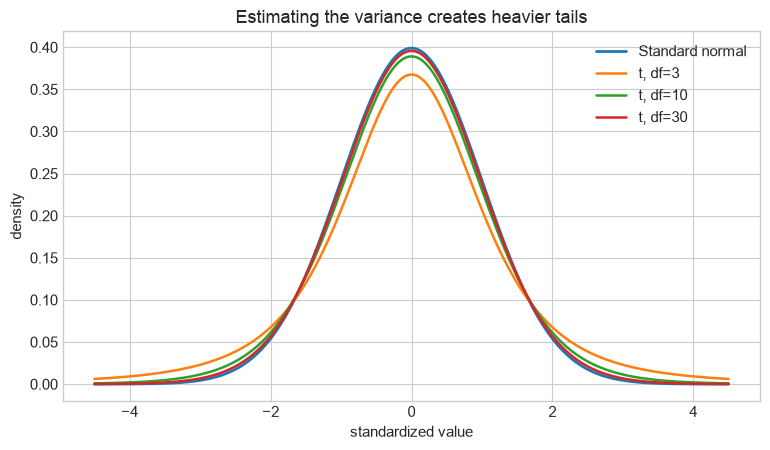

In [2]:
x = np.linspace(-4.5, 4.5, 1000)
fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x), lw=2, label="Standard normal")
for df in [3, 10, 30]:
    ax.plot(x, stats.t.pdf(x, df), lw=1.8, label=f"t, df={df}")
ax.set(title="Estimating the variance creates heavier tails", xlabel="standardized value", ylabel="density")
ax.legend()
plt.show()

### Why exactly does $T$ follow a Student t-distribution?

We now prove the statement rather than simply quote it.

**Proposition.** Assume that under $H_0$

$$X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}N(\mu_0,\sigma^2),\qquad \sigma>0,$$

and define

$$\bar X=\frac1n\sum_{i=1}^nX_i,\qquad S^2=\frac1{n-1}\sum_{i=1}^n(X_i-\bar X)^2.$$

Then

$$T=\frac{\bar X-\mu_0}{S/\sqrt n}\sim t_{n-1}.$$

#### Step 1: isolate the normal coordinate corresponding to the mean

Standardize the complete sample and write it as a vector:

$$\mathbf Y=\frac{\mathbf X-\mu_0\mathbf 1}{\sigma}\sim N_n(\mathbf 0,I_n),\qquad \mathbf e=\frac1{\sqrt n}(1,\ldots,1)^\top.$$

The unit vector $\mathbf e$ is the **mean direction**. The coordinate of $\mathbf Y$ in this direction is

$$Z=\mathbf e^\top\mathbf Y
=\frac{1}{\sqrt n\,\sigma}\sum_{i=1}^n(X_i-\mu_0)
=\frac{\sqrt n(\bar X-\mu_0)}{\sigma}.$$

A unit-length linear combination of independent $N(0,1)$ variables is again $N(0,1)$, so

$$Z\sim N(0,1).$$

#### Step 2: identify the residual coordinates and prove independence

Extend $\mathbf e$ to an orthonormal basis $\mathbf e,\mathbf e_2,\ldots,\mathbf e_n$ of $\mathbb R^n$. In this new coordinate system,

$$Z=\mathbf e^\top\mathbf Y,\qquad W_j=\mathbf e_j^\top\mathbf Y\quad(j=2,\ldots,n).$$

An orthogonal transformation of $N_n(\mathbf0,I_n)$ is still $N_n(\mathbf0,I_n)$. Therefore

$$Z,W_2,\ldots,W_n\overset{\mathrm{ind}}{\sim}N(0,1).$$

This is the crucial independence statement: the coordinate that estimates the mean is independent of all $n-1$ coordinates orthogonal to the mean direction.

The orthogonal residual vector is

$$\mathbf R=\mathbf Y-Z\mathbf e
=\frac1\sigma(X_1-\bar X,\ldots,X_n-\bar X)^\top.$$

Its squared length can be written in either coordinate system:

$$\|\mathbf R\|^2=\sum_{j=2}^nW_j^2
=\frac{1}{\sigma^2}\sum_{i=1}^n(X_i-\bar X)^2
=\frac{(n-1)S^2}{\sigma^2}=:U.$$

Because $U$ is the sum of the squares of $n-1$ independent standard normal variables,

$$U\sim\chi^2_{n-1},$$

and $U$ is independent of $Z$. This is also a special case of **Cochran's theorem**. Notice where the $n-1$ comes from: after removing the one-dimensional mean direction, the residual space has dimension $n-1$.

#### Step 3: apply the definition of Student's t-distribution

By definition, if $Z\sim N(0,1)$, $U\sim\chi^2_\nu$, and $Z$ and $U$ are independent, then

$$\frac{Z}{\sqrt{U/\nu}}\sim t_\nu.$$

Set $\nu=n-1$ and substitute the expressions just proved:

$$\begin{aligned}
\frac{Z}{\sqrt{U/(n-1)}}
&=\frac{\sqrt n(\bar X-\mu_0)/\sigma}
{\sqrt{[(n-1)S^2/\sigma^2]/(n-1)}}\\[4pt]
&=\frac{\sqrt n(\bar X-\mu_0)/\sigma}{S/\sigma}\\[4pt]
&=\frac{\bar X-\mu_0}{S/\sqrt n}=T.
\end{aligned}$$

Consequently,

$$\boxed{T=\frac{\bar X-\mu_0}{S/\sqrt n}\sim t_{n-1}.}$$

The unknown $\sigma$ disappears from the final ratio, but estimating it with the random quantity $S$ creates the heavier t tails. Independence between $Z$ and $U$ is essential; having a normal numerator and a chi-square denominator is not sufficient if they are dependent.

#### Exact scope of the result

- The result is **exact** when the observations are independent normal variables and $H_0:\mu=\mu_0$ is true.
- If the population is normal but its true mean is $\mu\ne\mu_0$, then $T$ follows a **noncentral t-distribution** with $n-1$ degrees of freedom and noncentrality $\delta=\sqrt n(\mu-\mu_0)/\sigma$.
- For non-normal populations, the finite-sample result is generally not exact. The t approximation is often useful for sufficiently large samples, provided dependence, strong skewness, heavy tails, and influential outliers are not serious.


In [ ]:
# Numerical confirmation of the theorem (an illustration, not a proof).
proof_rng = np.random.default_rng(123)
proof_repetitions, proof_n = 100_000, 6
normal_samples = proof_rng.normal(loc=0, scale=1, size=(proof_repetitions, proof_n))
proof_means = normal_samples.mean(axis=1)
proof_s = normal_samples.std(axis=1, ddof=1)
simulated_t = proof_means / (proof_s / np.sqrt(proof_n))
probabilities = np.array([0.01, 0.05, 0.50, 0.95, 0.99])

pl.DataFrame({
    "probability": probabilities,
    "simulated T quantile": np.quantile(simulated_t, probabilities),
    "theoretical t quantile": stats.t.ppf(probabilities, df=proof_n - 1),
}).with_columns(pl.exclude("probability").round(4))

## 4. A complete one-sample t-test by hand

We observe the following 12 fill measurements (mL) and test

$$H_0:\mu=30 \qquad\text{versus}\qquad H_1:\mu\ne30.$$


In [3]:
fills = np.array([29.4, 31.2, 30.8, 33.1, 28.9, 32.0,
                  31.6, 30.5, 32.4, 29.8, 31.9, 30.7])
mu0 = 30.0
n = fills.size
xbar = fills.mean()
s = fills.std(ddof=1)
se = s / np.sqrt(n)
t_observed = (xbar - mu0) / se
df = n - 1

pl.DataFrame({
    "quantity": ["sample size n", "sample mean", "sample SD s",
                 "standard error", "t statistic", "degrees of freedom"],
    "value": [float(n), float(xbar), float(s), float(se), float(t_observed), float(df)],
}).with_columns(pl.col("value").round(4))

quantity,value
str,f64
"""sample size n""",12.0
"""sample mean""",31.025
"""sample SD s""",1.2563
"""standard error""",0.3627
"""t statistic""",2.8262
"""degrees of freedom""",11.0


The statistic summarizes both **effect size in the sample** ($\bar x-30$) and **precision** ($s/\sqrt n$). The same observed difference produces a larger $|t|$ when the measurements are less variable or the sample is larger.

Do not confuse these quantities:

- $s$: spread of individual measurements;
- $s/\sqrt n$: estimated spread of sample means;
- $t$: difference from the null measured in standard-error units.


## 5. The p-value: a tail probability under $H_0$

For a two-sided test, values at least as incompatible with $H_0$ as the observed statistic lie in both tails. Thus

$$p=\Pr_{H_0}(|T_{n-1}|\ge |t_{\mathrm{obs}}|)
=2\Pr_{H_0}(T_{n-1}\ge |t_{\mathrm{obs}}|).$$

The subscript $H_0$ matters: the probability is calculated using the sampling distribution that would apply **if $H_0$ were true**. The p-value is a property of the data relative to a model, not the probability that a hypothesis is true.


two-sided p-value:  0.01648
H1: mu > 30 p-value: 0.00824
H1: mu < 30 p-value: 0.99176


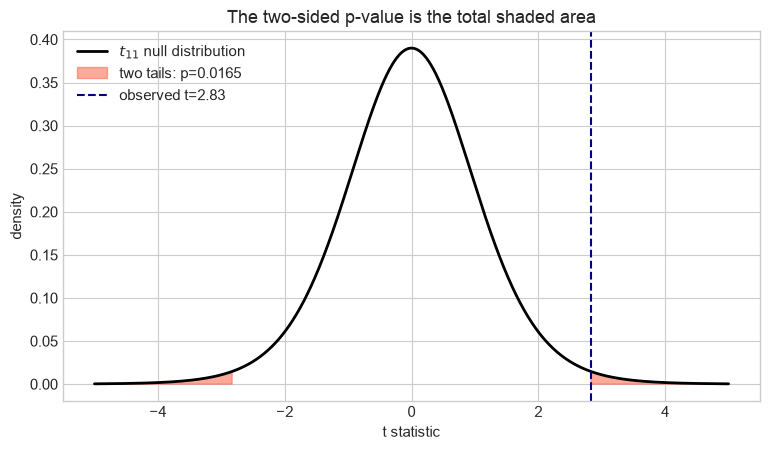

In [4]:
p_two_sided = 2 * stats.t.sf(abs(t_observed), df=df)
p_greater = stats.t.sf(t_observed, df=df)
p_less = stats.t.cdf(t_observed, df=df)

print(f"two-sided p-value:  {p_two_sided:.5f}")
print(f"H1: mu > 30 p-value: {p_greater:.5f}")
print(f"H1: mu < 30 p-value: {p_less:.5f}")

grid = np.linspace(-5, 5, 2000)
density = stats.t.pdf(grid, df)
fig, ax = plt.subplots()
ax.plot(grid, density, color="black", lw=2, label=f"$t_{{{df}}}$ null distribution")
tail = np.abs(grid) >= abs(t_observed)
ax.fill_between(grid, density, where=tail, color="tomato", alpha=0.55, label=f"two tails: p={p_two_sided:.4f}")
ax.axvline(t_observed, color="navy", ls="--", label=f"observed t={t_observed:.2f}")
ax.set(xlabel="t statistic", ylabel="density", title="The two-sided p-value is the total shaded area")
ax.legend()
plt.show()

### What a p-value does—and does not—say

A p-value of 0.03 means: **if $H_0$ and the model assumptions were true, the probability of obtaining a test statistic at least as extreme as the observed one is 3%.**

It does **not** mean:

- there is a 3% probability that $H_0$ is true;
- there is a 97% probability that $H_1$ is true;
- the result has a 3% probability of being due to chance;
- the effect is large or important;
- repeating the experiment has a 97% chance of producing significance.

Those statements would require additional ingredients, such as prior probabilities, a fully specified alternative, a decision model, or a replication-power calculation.


## 6. The decision rule and significance level $\alpha$

Before analyzing the data, choose a significance level $\alpha$, commonly 0.05. The rule is:

- if $p\le\alpha$, **reject $H_0$**;
- if $p>\alpha$, **fail to reject $H_0$**.

For a continuous test statistic under an exactly specified null model, this rule makes the long-run probability of rejecting a true $H_0$ equal to $\alpha$. It does not guarantee that any particular conclusion is correct.

Say **fail to reject**, not **accept $H_0$**. A non-small p-value may mean that $H_0$ is a good approximation, but it can also mean that the data are too noisy or the sample too small to reveal a real difference. Absence of evidence is not automatically evidence of absence. Equivalence or non-inferiority tests are designed for claims of practical sameness.


In [5]:
alpha = 0.05
scipy_result = stats.ttest_1samp(fills, popmean=mu0, alternative="two-sided")
critical_t = stats.t.ppf(1 - alpha / 2, df)

print(scipy_result)
print(f"Reject when |t| >= {critical_t:.4f}")
print("Decision:", "reject H0" if scipy_result.pvalue <= alpha else "fail to reject H0")
assert np.isclose(scipy_result.statistic, t_observed)
assert np.isclose(scipy_result.pvalue, p_two_sided)

TtestResult(statistic=np.float64(2.8262117758865397), pvalue=np.float64(0.01648348260996918), df=np.int64(11))
Reject when |t| >= 2.2010
Decision: reject H0


## 7. Confidence intervals and tests are two views of the same calculation

A two-sided $(1-\alpha)$ confidence interval for $\mu$ is

$$\bar x \pm t_{1-\alpha/2,n-1}\frac{s}{\sqrt n}.$$

The interpretation is procedural: if we repeatedly sampled and rebuilt intervals in this way, $(1-\alpha)100\%$ of them would contain the true $\mu$. Once an interval is computed, its endpoints are fixed; the frequentist procedure, not this particular interval, has 95% coverage.

For the same model and $\alpha$, a two-sided test rejects $H_0:\mu=\mu_0$ exactly when the $(1-\alpha)$ confidence interval excludes $\mu_0$. The interval is more informative because it shows the range of parameter values compatible with the data and their precision.


In [6]:
margin = critical_t * se
ci_95 = (xbar - margin, xbar + margin)
print(f"95% CI for the true mean: ({ci_95[0]:.3f}, {ci_95[1]:.3f}) mL")
print(f"Null value {mu0:.1f} is", "outside" if not ci_95[0] <= mu0 <= ci_95[1] else "inside", "the interval.")

95% CI for the true mean: (30.227, 31.823) mL
Null value 30.0 is outside the interval.


## 8. Two kinds of error and statistical power

A decision is made from incomplete information, so two errors are possible.

| Reality / decision | Fail to reject $H_0$ | Reject $H_0$ |
|---|---|---|
| $H_0$ is true | correct | **Type I error**, probability $\alpha$ |
| $H_1$ is true | **Type II error**, probability $\beta$ at a specified alternative | correct, probability $1-\beta$ |

The **power** $1-\beta$ is the probability that a test rejects $H_0$ when a particular alternative is true. Power is not one universal number: it depends on the true effect, noise, sample size, $\alpha$, test direction, and design.

Holding other quantities fixed:

- larger samples increase power;
- larger true effects increase power;
- less variable measurements increase power;
- increasing $\alpha$ increases power but also Type I error;
- a justified one-sided test has more power in its chosen direction but cannot detect the opposite direction.


Estimated Type I error at alpha=.05: 0.049
Estimated power for true mean 32:  0.559


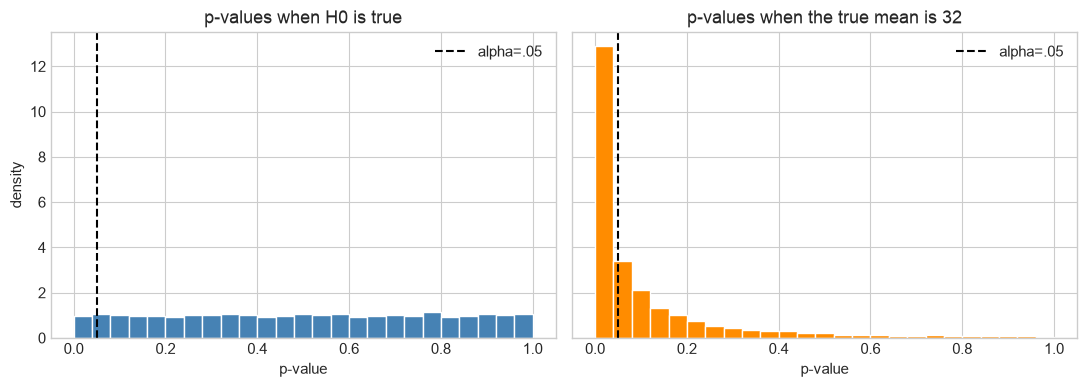

In [7]:
# Repeated experiments make the long-run meanings of alpha and power visible.
B, sim_n, sigma = 10_000, 12, 3.0

def simulated_pvalues(true_mean):
    samples = rng.normal(true_mean, sigma, size=(B, sim_n))
    means = samples.mean(axis=1)
    ses = samples.std(axis=1, ddof=1) / np.sqrt(sim_n)
    t_values = (means - mu0) / ses
    return 2 * stats.t.sf(np.abs(t_values), df=sim_n - 1)

p_under_h0 = simulated_pvalues(true_mean=30.0)
p_under_h1 = simulated_pvalues(true_mean=32.0)
print(f"Estimated Type I error at alpha=.05: {(p_under_h0 < .05).mean():.3f}")
print(f"Estimated power for true mean 32:  {(p_under_h1 < .05).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
bins = np.linspace(0, 1, 26)
axes[0].hist(p_under_h0, bins=bins, density=True, color="steelblue", edgecolor="white")
axes[0].set(title="p-values when H0 is true", xlabel="p-value", ylabel="density")
axes[1].hist(p_under_h1, bins=bins, density=True, color="darkorange", edgecolor="white")
axes[1].set(title="p-values when the true mean is 32", xlabel="p-value")
for ax in axes:
    ax.axvline(0.05, color="black", ls="--", label="alpha=.05")
    ax.legend()
plt.tight_layout()
plt.show()

Under a true continuous null hypothesis, p-values are uniformly distributed: about 5% fall below 0.05. Under a particular alternative, they concentrate near zero; the fraction below $\alpha$ is the power for that alternative.


## 9. Statistical significance is not practical significance

A p-value mixes effect magnitude with precision. With enormous $n$, a negligible effect can be significant; with small $n$, an important effect can be missed. Always accompany a test with:

1. the estimated effect (here $\bar x-\mu_0$);
2. a confidence interval;
3. domain knowledge about what difference matters;
4. optionally, a standardized effect size.

For a one-sample design, Cohen's $d$ is

$$d=\frac{\bar x-\mu_0}{s}.$$

It measures the observed difference in sample-standard-deviation units. Conventional labels such as “small” or “large” are context-dependent and should not replace subject-matter judgment.


In [8]:
mean_difference = xbar - mu0
cohens_d = mean_difference / s
print(f"Estimated mean difference: {mean_difference:.3f} mL")
print(f"Cohen's d: {cohens_d:.3f}")
print("Notice the identity t = d * sqrt(n):", np.isclose(t_observed, cohens_d * np.sqrt(n)))

Estimated mean difference: 1.025 mL
Cohen's d: 0.816
Notice the identity t = d * sqrt(n): True


## 10. Which t-test should you use?

All t-tests compare a difference to its estimated standard error. What changes is the design and therefore the standard error.

| Design | Parameter tested | Recommended test | Degrees of freedom |
|---|---|---|---|
| one sample versus a reference | $\mu-\mu_0$ | one-sample t-test | $n-1$ |
| same units measured twice or matched pairs | $\mu_D$, where $D=X-Y$ | paired t-test on differences | number of pairs $-1$ |
| two independent groups | $\mu_1-\mu_2$ | Welch t-test | Welch–Satterthwaite approximation |
| two independent groups with equal variances justified | $\mu_1-\mu_2$ | pooled t-test | $n_1+n_2-2$ |

**Default for independent groups:** use Welch's test. It does not assume equal population variances and loses little precision when variances are equal. Pairing is a property of the study design, not something inferred from similar sample sizes.


### 10.1 Paired t-test

Suppose each student's score is recorded before and after instruction. The observations within a student are dependent, but the **differences across students** may be independent. Define $D_i=\text{after}_i-\text{before}_i$ and test

$$H_0:\mu_D=0 \qquad\text{using}\qquad T=\frac{\bar D}{S_D/\sqrt n}.$$

So a paired t-test is exactly a one-sample t-test applied to the within-pair differences. It controls for stable between-person variation and can be much more precise than incorrectly treating the two measurements as independent.


In [9]:
before = np.array([68, 75, 71, 64, 80, 73, 69, 77, 66, 72])
after  = np.array([72, 78, 70, 69, 84, 76, 74, 79, 70, 75])
differences = after - before
paired = stats.ttest_rel(after, before, alternative="two-sided")
same_as_one_sample = stats.ttest_1samp(differences, popmean=0)

print(f"Differences: {differences}")
print(f"Mean improvement: {differences.mean():.2f} points")
print("Paired test:       ", paired)
print("One-sample on D:   ", same_as_one_sample)
assert np.allclose(paired, same_as_one_sample)

Differences: [ 4  3 -1  5  4  3  5  2  4  3]
Mean improvement: 3.20 points
Paired test:        TtestResult(statistic=np.float64(5.778520948116922), pvalue=np.float64(0.00026656071708311245), df=np.int64(9))
One-sample on D:    TtestResult(statistic=np.float64(5.778520948116922), pvalue=np.float64(0.00026656071708311245), df=np.int64(9))


### 10.2 Two independent groups: Welch's t-test

For independent groups with means $\bar X_1,\bar X_2$, variances $s_1^2,s_2^2$, and sizes $n_1,n_2$, Welch's statistic is

$$T=\frac{(\bar X_1-\bar X_2)-\Delta_0}{\sqrt{s_1^2/n_1+s_2^2/n_2}},$$

usually with $\Delta_0=0$. Its approximate degrees of freedom are

$$\nu=\frac{(s_1^2/n_1+s_2^2/n_2)^2}{(s_1^2/n_1)^2/(n_1-1)+(s_2^2/n_2)^2/(n_2-1)}.$$

The df need not be an integer. The pooled test replaces both variances with one shared estimate and is valid only when the population variances can reasonably be treated as equal. Do not choose between pooled and Welch solely from a preliminary variance test; that two-stage strategy has unstable properties.


In [10]:
method_a = np.array([18, 21, 20, 19, 24, 22, 17, 23, 20])
method_b = np.array([15, 19, 14, 23, 18, 16, 25, 17, 20, 13, 22, 16])
n1, n2 = len(method_a), len(method_b)
m1, m2 = method_a.mean(), method_b.mean()
v1, v2 = method_a.var(ddof=1), method_b.var(ddof=1)
welch_se = np.sqrt(v1 / n1 + v2 / n2)
welch_t = (m1 - m2) / welch_se
welch_df = (v1 / n1 + v2 / n2)**2 / ((v1 / n1)**2 / (n1 - 1) + (v2 / n2)**2 / (n2 - 1))
welch_p = 2 * stats.t.sf(abs(welch_t), welch_df)
welch_ci_margin = stats.t.ppf(0.975, welch_df) * welch_se
welch_ci = ((m1 - m2) - welch_ci_margin, (m1 - m2) + welch_ci_margin)
scipy_welch = stats.ttest_ind(method_a, method_b, equal_var=False)

print(f"Mean difference A-B: {m1-m2:.3f}")
print(f"Welch t({welch_df:.2f}) = {welch_t:.3f}, p = {welch_p:.4f}")
print(f"95% CI for A-B: ({welch_ci[0]:.3f}, {welch_ci[1]:.3f})")
print("SciPy check:", scipy_welch)
assert np.allclose([welch_t, welch_p], [scipy_welch.statistic, scipy_welch.pvalue])

Mean difference A-B: 2.278
Welch t(18.44) = 1.722, p = 0.1019
95% CI for A-B: (-0.497, 5.053)
SciPy check: TtestResult(statistic=np.float64(1.7215621528696814), pvalue=np.float64(0.10188243284926751), df=np.float64(18.43971098870932))


## 11. Assumptions: what must be true?

A test's conclusion is only as credible as its design and model.

### Essential design assumptions

1. **Independence across observational units.** This comes from sampling or randomization, not from a histogram. Repeated measurements, families, classrooms, time series, or spatial neighbors require a model that represents their dependence.
2. **The sample answers the target question.** Convenience samples may give precise answers about the wrong population. Random assignment supports causal claims; a small p-value alone does not.
3. **A quantitative outcome and an appropriate mean comparison.** Severe censoring or a scale for which a mean is meaningless calls for another method.

### Distributional assumptions

- The exact small-sample t theory assumes a normal population (normal **differences** for a paired test).
- t-tests are often robust to moderate non-normality, especially with balanced or larger samples, because sample means become approximately normal.
- Strong skewness, heavy tails, or outliers can be serious for small samples because means and standard deviations are sensitive to them.
- Welch's test allows unequal variances; the pooled independent test does not.

Inspect the data, but do not turn diagnostics into mechanical pass/fail rituals. A Q–Q plot assesses whether the ordered observations approximately follow normal quantiles; it cannot verify independence or representativeness.


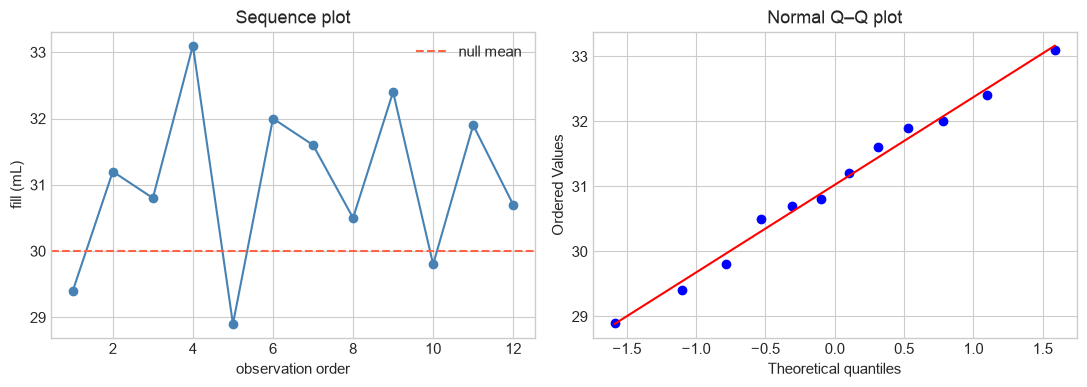

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, n + 1), fills, "o-", color="steelblue")
axes[0].axhline(mu0, color="tomato", ls="--", label="null mean")
axes[0].set(xlabel="observation order", ylabel="fill (mL)", title="Sequence plot")
axes[0].legend()
stats.probplot(fills, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q–Q plot")
plt.tight_layout()
plt.show()

### If assumptions are doubtful

There is no universal replacement. The choice depends on the estimand—the population quantity you actually want. Possible responses include checking data errors, using a scientifically justified transformation, a robust method, a permutation/randomization test compatible with the design, or a bootstrap confidence interval. Rank-based tests such as Wilcoxon or Mann–Whitney generally test different hypotheses and should not be described automatically as tests of means.


## 12. Multiple testing and researcher choices

If $m$ independent true null hypotheses are each tested at level $\alpha$, the probability of at least one false rejection is

$$1-(1-\alpha)^m.$$

For 20 tests at $\alpha=0.05$, this is about 64%, not 5%. A Bonferroni correction tests each hypothesis at $\alpha/m$ and controls the family-wise error rate without requiring independence. Holm's step-down procedure is usually at least as powerful. False-discovery-rate procedures answer a different question and are useful when many discoveries are expected.

Undisclosed flexibility—trying several outcomes, exclusions, transformations, or stopping rules and reporting only a small p-value—creates the same basic problem. Pre-specification, transparent reporting, and replication protect the interpretation.


In [12]:
m = 20
family_error_if_independent = 1 - (1 - alpha)**m
bonferroni_threshold = alpha / m
print(f"P(at least one false positive among {m} independent tests): {family_error_if_independent:.3f}")
print(f"Bonferroni per-test threshold: {bonferroni_threshold:.4f}")

P(at least one false positive among 20 independent tests): 0.642
Bonferroni per-test threshold: 0.0025


## 13. Beyond t-tests: ADF and KPSS tests for time-series stationarity

ADF and KPSS are useful examples of why one must read $H_0$ before interpreting a p-value: **their null hypotheses point in opposite directions**. They are not ordinary t-tests, even though the ADF statistic looks like a regression t-statistic.

### 13.1 What does stationary mean?

A process $(Y_t)$ is **weakly (covariance) stationary** when

$$\mathbb E[Y_t]=\mu,\qquad \operatorname{Var}(Y_t)=\gamma(0)<\infty,\qquad \operatorname{Cov}(Y_t,Y_{t-h})=\gamma(h),$$

so its mean and variance do not depend on calendar time and its covariance depends only on the lag $h$. Stationarity is a property of the stochastic process, not merely of whether one plotted realization looks flat.

Compare two AR(1) processes:

$$Y_t=\rho Y_{t-1}+\varepsilon_t,\qquad \varepsilon_t\overset{\mathrm{iid}}{\sim}(0,\sigma_\varepsilon^2).$$

If $|\rho|<1$, shocks decay geometrically and the stationary solution is

$$Y_t=\sum_{j=0}^{\infty}\rho^j\varepsilon_{t-j},\qquad \operatorname{Var}(Y_t)=\frac{\sigma_\varepsilon^2}{1-\rho^2}.$$

If $\rho=1$, there is a **unit root** and

$$Y_t=Y_{t-1}+\varepsilon_t=Y_0+\sum_{j=1}^t\varepsilon_j,\qquad \operatorname{Var}(Y_t)=t\sigma_\varepsilon^2.$$

This random walk is not stationary: its variance grows with time and every shock has a permanent effect. Its first difference $\Delta Y_t=Y_t-Y_{t-1}=\varepsilon_t$ is stationary, so it is called **difference-stationary** or $I(1)$. In contrast, $Y_t=a+bt+u_t$ with stationary $u_t$ is **trend-stationary**: removing the deterministic trend, rather than differencing, makes it stationary.


In [ ]:
# Two processes with the same innovation variance but very different persistence.
ts_rng = np.random.default_rng(2027)
series_length, burn_in, rho = 300, 200, 0.60
ar_innovations = ts_rng.normal(size=series_length + burn_in)
ar_process = np.zeros(series_length + burn_in)
for time_index in range(1, series_length + burn_in):
    ar_process[time_index] = rho * ar_process[time_index - 1] + ar_innovations[time_index]
stationary_ar = ar_process[burn_in:]
random_walk = np.cumsum(ts_rng.normal(size=series_length))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(stationary_ar, color="steelblue")
axes[0].axhline(stationary_ar.mean(), color="black", ls="--", lw=1)
axes[0].set(title="Stationary AR(1): rho = 0.60", xlabel="time", ylabel="value")
axes[1].plot(random_walk, color="darkorange")
axes[1].set(title="Unit-root process: random walk, rho = 1", xlabel="time")
plt.tight_layout()
plt.show()

### 13.2 ADF: the null hypothesis is a unit root

Start with the AR(1) model

$$Y_t=c+\rho Y_{t-1}+\varepsilon_t.$$

Subtract $Y_{t-1}$ from both sides and define $\gamma=\rho-1$:

$$\Delta Y_t=c+\gamma Y_{t-1}+\varepsilon_t.$$

Therefore testing $\rho=1$ is equivalent to testing $\gamma=0$:

$$H_0:\gamma=0\quad(\rho=1,\text{ unit root})$$

$$H_1:-2<\gamma<0\quad(|\rho|<1,\text{ stationary under the chosen deterministic specification}).$$

If the errors are serially correlated, the **augmented** Dickey–Fuller regression includes lagged differences:

$$\Delta Y_t=a+bt+\gamma Y_{t-1}+\sum_{i=1}^{p}\phi_i\Delta Y_{t-i}+\varepsilon_t.$$

The lagged differences absorb short-run dynamics so that $\varepsilon_t$ is approximately uncorrelated. The deterministic terms must match the scientific model:

- no constant or trend: stationary alternative around zero;
- constant: level-stationary alternative around a nonzero mean;
- constant and trend: trend-stationary alternative.

The ADF statistic is

$$\tau_{\mathrm{ADF}}=\frac{\widehat\gamma}{\operatorname{SE}(\widehat\gamma)}.$$

Very negative values contradict $H_0$, so this is a **left-tail test**:

$$p_{\mathrm{ADF}}=\Pr_{H_0}(\tau\le\tau_{\mathrm{obs}}).$$

#### Why the ADF statistic is not Student t under $H_0$

Although $\tau_{\mathrm{ADF}}$ has the algebraic form coefficient divided by standard error, under $H_0$ the regressor $Y_{t-1}$ is itself a random walk. The usual stationary-regression central limit theorem does not apply. In the simplest model without deterministic terms, the functional central limit theorem gives

$$\tau_{\mathrm{ADF}}\;\Longrightarrow\;
\frac{\int_0^1 W(r)\,dW(r)}{\left[\int_0^1W(r)^2\,dr\right]^{1/2}},$$

where $W$ is standard Brownian motion. This is a **Dickey–Fuller distribution**, not $t_{n-k}$. Adding a constant or trend replaces $W$ by a demeaned or detrended Brownian-motion functional, so the critical values depend on the deterministic specification. Software normally reports MacKinnon approximations. Never compare an ADF statistic with the ordinary values $-1.96$ or $-1.645$.


In [ ]:
def adf_regression_statistic(series, lags=0):
    """ADF coefficient statistic with a constant and a fixed number of lagged differences."""
    if not isinstance(lags, (int, np.integer)) or lags < 0:
        raise ValueError("lags must be a non-negative integer.")
    y = np.asarray(series, dtype=float)
    if y.ndim != 1 or y.size <= lags + 3 or np.isnan(y).any():
        raise ValueError("Provide a one-dimensional, non-missing series long enough for the chosen lags.")

    differences = np.diff(y)
    response = differences[lags:]
    columns = [np.ones(response.size), y[lags:-1]]
    for lag in range(1, lags + 1):
        columns.append(differences[lags - lag:-lag])
    design = np.column_stack(columns)

    coefficients, *_ = np.linalg.lstsq(design, response, rcond=None)
    residuals = response - design @ coefficients
    residual_df = response.size - design.shape[1]
    residual_variance = residuals @ residuals / residual_df
    covariance = residual_variance * np.linalg.inv(design.T @ design)
    gamma_hat = coefficients[1]
    gamma_se = np.sqrt(covariance[1, 1])
    return {
        "gamma_hat": float(gamma_hat),
        "gamma_se": float(gamma_se),
        "adf_statistic": float(gamma_hat / gamma_se),
        "regression_observations": int(response.size),
    }

adf_lags = 2
# Approximate asymptotic 5% critical value for the constant-only specification.
# Production software uses sample-size-adjusted MacKinnon values.
adf_critical_5pct = -2.86
adf_rows = []
for series_name, series_values in {"stationary AR(1)": stationary_ar, "random walk": random_walk}.items():
    result = adf_regression_statistic(series_values, lags=adf_lags)
    adf_rows.append({
        "series": series_name,
        "gamma_hat": result["gamma_hat"],
        "ADF statistic": result["adf_statistic"],
        "5% critical value": adf_critical_5pct,
        "decision about unit-root H0": (
            "reject H0" if result["adf_statistic"] < adf_critical_5pct else "fail to reject H0"
        ),
    })

adf_results = pl.DataFrame(adf_rows).with_columns(
    pl.col("gamma_hat", "ADF statistic", "5% critical value").round(4)
)
adf_results

For the simulated stationary AR(1), $\widehat\gamma$ is clearly negative and the ADF statistic falls far into the left tail, so we reject the unit-root null. For the random walk, the statistic is not sufficiently negative, so we fail to reject a unit root.

**Important:** failing to reject the ADF null does not prove that a unit root exists. The test can have low power against a highly persistent alternative such as $\rho=0.98$, especially in short samples.


### 13.3 KPSS: the null hypothesis is stationarity

KPSS deliberately reverses the null. Its structural model is

$$Y_t=d_t+r_t+\varepsilon_t,\qquad r_t=r_{t-1}+u_t,$$

where $d_t$ is a constant or deterministic trend, $\varepsilon_t$ is stationary, and $r_t$ is a random-walk component with $\operatorname{Var}(u_t)=\sigma_u^2$. Then

$$H_0:\sigma_u^2=0\quad(\text{no random-walk component; stationary around }d_t),$$

$$H_1:\sigma_u^2>0\quad(\text{a stochastic-trend or unit-root component is present}).$$

First remove the deterministic component $d_t$ by regression and call the residuals $e_t$. For level stationarity, $e_t=Y_t-\bar Y$. Form their partial sums

$$C_t=\sum_{i=1}^t e_i.$$

If $e_t$ is stationary, its partial sums fluctuate on the order of $\sqrt n$. A stochastic trend makes them wander much more strongly. KPSS measures their accumulated squared magnitude:

$$\eta_{\mathrm{KPSS}}=\frac{1}{n^2\widehat\omega^2}\sum_{t=1}^nC_t^2,$$

where $\widehat\omega^2$ is a heteroskedasticity-and-autocorrelation-consistent estimate of the long-run variance. With Bartlett weights and truncation lag $L$,

$$\widehat\omega^2=\widehat\gamma_0+2\sum_{j=1}^{L}\left(1-\frac{j}{L+1}\right)\widehat\gamma_j,\qquad
\widehat\gamma_j=\frac1n\sum_{t=j+1}^ne_te_{t-j}.$$

Under a level-stationary null, normalized partial sums converge to a Brownian bridge $B_0$, giving the nonstandard limit

$$\eta_{\mathrm{KPSS}}\;\Longrightarrow\;\int_0^1B_0(r)^2\,dr.$$

Large $\eta$ contradicts stationarity, so KPSS is a **right-tail test**:

$$p_{\mathrm{KPSS}}=\Pr_{H_0}(\eta\ge\eta_{\mathrm{obs}}).$$

For the level-stationary specification, the asymptotic critical values at 10%, 5%, 2.5%, and 1% are approximately 0.347, 0.463, 0.574, and 0.739. The bandwidth $L$ matters: too few lags under-correct serial correlation; too many can reduce power.


In [ ]:
def kpss_level_statistic(series, lags):
    """KPSS statistic for level stationarity with Bartlett/Newey-West weights."""
    y = np.asarray(series, dtype=float)
    if y.ndim != 1 or y.size < 3 or np.isnan(y).any():
        raise ValueError("Provide a one-dimensional, non-missing series with at least three values.")
    if not isinstance(lags, (int, np.integer)) or not 0 <= lags < y.size:
        raise ValueError("lags must be an integer between 0 and n - 1.")

    n = y.size
    residuals = y - y.mean()
    partial_sums = np.cumsum(residuals)
    long_run_variance = residuals @ residuals / n
    for lag in range(1, lags + 1):
        autocovariance = residuals[lag:] @ residuals[:-lag] / n
        bartlett_weight = 1 - lag / (lags + 1)
        long_run_variance += 2 * bartlett_weight * autocovariance

    statistic = np.sum(partial_sums**2) / (n**2 * long_run_variance)
    return {"kpss_statistic": float(statistic), "long_run_variance": float(long_run_variance)}

kpss_lags = 8
kpss_critical_5pct = 0.463  # Level-stationary null (constant removed).
kpss_rows = []
for series_name, series_values in {"stationary AR(1)": stationary_ar, "random walk": random_walk}.items():
    result = kpss_level_statistic(series_values, lags=kpss_lags)
    kpss_rows.append({
        "series": series_name,
        "KPSS statistic": result["kpss_statistic"],
        "5% critical value": kpss_critical_5pct,
        "decision about stationarity H0": (
            "reject H0" if result["kpss_statistic"] > kpss_critical_5pct else "fail to reject H0"
        ),
    })

kpss_results = pl.DataFrame(kpss_rows).with_columns(
    pl.col("KPSS statistic", "5% critical value").round(4)
)
kpss_results

### 13.4 Read ADF and KPSS together

At a fixed significance level, combine the decisions rather than asking which test is universally better:

| ADF: unit-root $H_0$ | KPSS: stationarity $H_0$ | Practical reading |
|---|---|---|
| reject | fail to reject | evidence favors stationarity |
| fail to reject | reject | evidence favors a unit root / nonstationarity |
| fail to reject | fail to reject | data are inconclusive; both nulls remain plausible |
| reject | reject | conflict: inspect deterministic terms, breaks, lag choices, seasonality, and model misspecification |

The second row is what the random-walk simulation should produce; the first is what the stationary AR(1) should produce. “Fail to reject” still does not mean “accept.” Using complementary nulls creates an **indifference region** (neither rejected) and a **conflict region** (both rejected), which honestly expose uncertainty.

### 13.5 Important limitations

- ADF targets a unit root, not every possible form of nonstationarity. KPSS targets stationarity around the specified constant or trend.
- Structural breaks can make a stationary process look like a unit root and can cause both tests to reject.
- Deterministic components must be chosen scientifically: omitting a real trend or adding an unnecessary one changes power and critical values.
- ADF lag length and KPSS bandwidth affect results. Check that ADF residual autocorrelation is adequately removed and perform sensitivity analysis.
- Seasonal unit roots require seasonal tests; nonlinear or regime-switching dynamics may require other models.
- Testing should support, not replace, plots, domain knowledge, and examination of transformations and breaks.

Official API references: [statsmodels ADF documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) and [statsmodels KPSS documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html).


In [ ]:
# Optional production-library comparison. The notebook's manual implementations above
# remain fully runnable when statsmodels is absent.
try:
    from statsmodels.tsa.stattools import adfuller, kpss
except ModuleNotFoundError:
    print("Optional check skipped: statsmodels is not installed in this environment.")
else:
    library_rows = []
    for series_name, series_values in {"stationary AR(1)": stationary_ar, "random walk": random_walk}.items():
        adf_output = adfuller(series_values, maxlag=adf_lags, regression="c", autolag=None)
        kpss_output = kpss(series_values, regression="c", nlags=kpss_lags)
        library_rows.append({
            "series": series_name,
            "ADF statistic": adf_output[0],
            "ADF p-value": adf_output[1],
            "KPSS statistic": kpss_output[0],
            "KPSS p-value": kpss_output[1],
        })
    library_results = pl.DataFrame(library_rows).with_columns(pl.exclude("series").round(4))
    print(library_results)


### 13.6 Stationarity self-checks

1. An ADF test returns $p=0.01$. Which null is rejected, and what conclusion is supported?
2. A KPSS test returns $p=0.01$. Why does this point in the opposite direction?
3. Why may the ADF coefficient statistic not be compared with an ordinary Student t critical value?
4. Change `rho` from 0.60 to 0.98 and regenerate the AR process. How often does ADF fail to reject despite $\rho<1$? This illustrates low power near the unit-root boundary.
5. Add a deterministic linear trend to `stationary_ar`. Explain why a constant-only test is misspecified and which deterministic specification should replace it.

<details>
<summary><strong>Answers to the first three checks</strong></summary>

1. Reject the ADF null of a unit root; the data support stationarity under the included deterministic terms.

2. Reject the KPSS null of stationarity; the data support nonstationarity. A small p-value always rejects the test's own $H_0$, but ADF and KPSS define different $H_0$.

3. Under the unit-root null, the lagged level is nonstationary, so the statistic converges to a Brownian-motion functional rather than a Student t-distribution.

</details>


## 14. A reusable one-sample workflow

A sound analysis can be organized in seven steps:

1. State the population, parameter, and scientific question.
2. Specify $H_0$, $H_1$, test direction, and $\alpha$ before seeing the result.
3. Check the study design, independence, data quality, and distributional concerns.
4. Compute the estimate, standard error, test statistic, degrees of freedom, and p-value.
5. Quantify uncertainty with a confidence interval.
6. Discuss magnitude and practical relevance, not only significance.
7. Report limitations and the scope of the conclusion.


In [13]:
def one_sample_t_summary(data, null_mean=0.0, alpha=0.05, alternative="two-sided"):
    """Return the essential quantities for a one-sample t-test."""
    x = np.asarray(data, dtype=float)
    x = x[~np.isnan(x)]
    if x.size < 2:
        raise ValueError("At least two non-missing observations are required.")
    if alternative not in {"two-sided", "less", "greater"}:
        raise ValueError("alternative must be 'two-sided', 'less', or 'greater'.")

    n = x.size
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    result = stats.ttest_1samp(x, popmean=null_mean, alternative=alternative)
    df = n - 1

    # This confidence interval is the usual two-sided interval, independent of
    # the chosen test direction. One-sided intervals would use other endpoints.
    critical = stats.t.ppf(1 - alpha / 2, df)
    ci_low, ci_high = mean - critical * se, mean + critical * se

    summary = {
        "n": n, "mean": mean, "sd": sd, "se": se,
        "mean_minus_null": mean - null_mean,
        "t": result.statistic, "df": df, "p_value": result.pvalue,
        f"{100*(1-alpha):.0f}%_ci_low": ci_low,
        f"{100*(1-alpha):.0f}%_ci_high": ci_high,
        "cohens_d": (mean - null_mean) / sd,
    }
    return pl.DataFrame({name: [value] for name, value in summary.items()})

one_sample_t_summary(fills, null_mean=30).with_columns(pl.exclude("n").round(4))

n,mean,sd,se,mean_minus_null,t,df,p_value,95%_ci_low,95%_ci_high,cohens_d
i64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64
12,31.025,1.2563,0.3627,1.025,2.8262,11,0.0165,30.2268,31.8232,0.8159


### Example report

> The 12 observed vials had a mean fill of 31.03 mL (SD 1.26). A two-sided one-sample t-test found evidence that the population mean differs from 30 mL, $t(11)=2.83$, $p=.016$. The estimated difference was 1.03 mL, with a 95% confidence interval of approximately [0.23, 1.82] mL (Cohen's $d=0.82$). This inference assumes the sampled vials are independent and representative of the production process and that the small-sample normal model is adequate.

A report should name the test, give the estimate and uncertainty, state the direction and units, and connect the result back to the scientific question. Exact values in the output cells are authoritative; the rounded prose is for communication.


## 15. Common mistakes checklist

- Treating $p$ as $\Pr(H_0\mid\text{data})$ rather than $\Pr(\text{data at least this extreme}\mid H_0)$.
- Saying “accept $H_0$” after a non-significant result.
- Choosing a one-sided alternative after seeing the direction.
- Equating statistical significance with a large or useful effect.
- Ignoring dependence, selection bias, outliers, optional stopping, or multiple comparisons.
- Using a paired test without real pairs, or ignoring genuine pairs.
- Automatically using the pooled two-sample test when Welch's test is safer.
- Believing normality of raw data is always required even for large samples—or that large $n$ repairs biased sampling or dependence.
- Interpreting a confidence interval as containing 95% of observations. It concerns the parameter, not individual data points.
- Treating failure to reject the ADF unit-root null as proof of a unit root, or failure to reject the KPSS stationarity null as proof of stationarity.
- Applying ADF or KPSS without justifying deterministic terms, lag/bandwidth choices, or checking for structural and seasonal breaks.
- Reporting only “$p<.05$” without the estimate, confidence interval, sample size, and design context.


## 16. Exercises

1. **Interpretation.** A test gives $p=0.08$ at $\alpha=0.05$. What is the decision? Name two conclusions that are *not* justified.
2. **By hand.** For $n=16$, $\bar x=52$, $s=8$, test $H_0:\mu=50$ versus $H_1:\mu\ne50$. Compute the standard error, $t$, df, and p-value.
3. **Direction.** A treatment could plausibly help or harm. Should the primary test be one-sided or two-sided, and why?
4. **Design.** Blood pressure is measured on the same 25 people before and after treatment. Which t-test applies, and what observations must be approximately normal for exact small-sample inference?
5. **Independent groups.** Modify `method_a` so its variance is much larger, then compare `equal_var=False` and `equal_var=True`. Explain why their standard errors and degrees of freedom differ.
6. **Power.** In the simulation, vary `sim_n`, `sigma`, and the alternative mean. Describe what happens to power and why.
7. **Multiple tests.** Calculate $1-(1-.05)^{100}$. Why is reporting the smallest of 100 unadjusted p-values misleading?
8. **Critical thinking.** A huge observational dataset finds a mean difference of 0.01 units with $p<10^{-8}$. List three questions you would ask before calling the result important or causal.


<details>
<summary><strong>Selected answers</strong></summary>

1. Fail to reject $H_0$. This does not prove $H_0$, and 0.08 is not the probability that $H_0$ is true.

2. $SE=8/\sqrt{16}=2$, $t=(52-50)/2=1$, $df=15$, and the two-sided p-value is about 0.333.

3. Two-sided, because both scientifically plausible directions matter.

4. A paired t-test. For the exact test, the 25 within-person differences—not the two marginal samples separately—should be independent and normally distributed.

7. The probability is about 0.994. Selecting only the smallest result hides a very high opportunity for a false positive.

8. Ask about the effect's units and practical threshold, confidence interval, sampling and confounding, measurement quality, dependence, multiplicity, and whether the analysis was pre-specified.

</details>


## Final mental model

A hypothesis test is a calibrated incompatibility check:

$$\boxed{\text{question} \to (H_0,H_1) \to \text{sampling model} \to \frac{\text{signal}}{\text{noise}} \to p \to \text{decision and uncertainty}}$$

The p-value asks how extreme the data are under $H_0$. The significance level controls a long-run Type I error rate. The confidence interval shows effect sizes compatible with the data. Power describes the test's ability to detect specified alternatives. None of these can rescue a poorly designed study, and none alone measures practical importance.

The deepest habit is simple: **separate the mathematical calculation from the scientific conclusion, then justify the bridge between them.**

### Further reading

- George Casella and Roger L. Berger, *Statistical Inference*.
- Larry Wasserman, *All of Statistics*.
- David Freedman, Robert Pisani, and Roger Purves, *Statistics*.
- American Statistical Association, *Statement on Statistical Significance and P-Values* (2016).
